# 📱 Megaline Plan Recommender
## Clasificación supervisada para recomendación de planes móviles

---

**Empresa:** Megaline — operadora móvil  
**Problema:** Miles de clientes siguen usando planes heredados. El equipo comercial necesita una herramienta que recomiende automáticamente el plan correcto a cada cliente.  
**Objetivo:** Construir un modelo de clasificación que prediga si un cliente debe estar en el plan **Smart** o **Ultra** basado en su comportamiento de uso mensual.  
**Umbral de exactitud requerido:** ≥ 0.75  

---

### Variables del dataset

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `calls` | Numérica | Número de llamadas en el mes |
| `minutes` | Numérica | Duración total de llamadas en minutos |
| `messages` | Numérica | Número de mensajes de texto enviados |
| `mb_used` | Numérica | Tráfico de internet consumido en MB |
| `is_ultra` | Binaria | Plan actual: Ultra (1) o Smart (0) |

---

### Estructura del proyecto

| Sección | Contenido |
|---------|-----------|
| 1 | Carga e inspección inicial |
| 2 | Análisis exploratorio |
| 3 | Visualizaciones |
| 4 | Segmentación de datos |
| 5 | Entrenamiento de modelos |
| 6 | Comparación de modelos |
| 7 | Evaluación final en test |
| 8 | Prueba de cordura |
| 9 | Conclusiones |

## Sección 1 — Carga e inspección inicial

Cargamos el dataset y verificamos su estructura básica: dimensiones, tipos de datos, valores nulos y duplicados. El objetivo es confirmar que los datos están listos para trabajar sin necesidad de limpieza.

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

SEED = 42
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

In [71]:
df = pd.read_csv('users_behavior.csv')

print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
print(f'Nulos:    {df.isnull().sum().sum()}')
print(f'Duplicados: {df.duplicated().sum()}')
print()
df.head(10)

Filas:    3,214
Columnas: 5
Nulos:    0
Duplicados: 0



,calls,minutes,messages,mb_used,is_ultra
0,40.0,311.90,83.0,19915.42,0
1,85.0,516.75,56.0,22696.96,0
2,77.0,467.66,86.0,21060.45,0
3,106.0,745.53,81.0,8437.39,1
4,66.0,418.74,1.0,14502.75,0
5,58.0,344.56,21.0,15823.37,0
6,57.0,431.64,20.0,3738.90,1
7,15.0,132.40,6.0,21911.60,0
8,7.0,43.39,3.0,2538.67,1
9,90.0,665.41,38.0,17358.61,0


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   calls     3214 non-null   float64
 1   minutes   3214 non-null   float64
 2   messages  3214 non-null   float64
 3   mb_used   3214 non-null   float64
 4   is_ultra  3214 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 125.7 KB


## Sección 2 — Análisis exploratorio

Antes de construir cualquier modelo necesitamos entender qué hay en los datos. Esta sección responde tres preguntas: ¿cómo se distribuyen los valores de cada variable? ¿Están las clases balanceadas? ¿Qué diferencias de comportamiento existen entre usuarios Smart y Ultra?

### 2a — Estadísticas descriptivas

Calculamos media, desviación estándar, mínimo, máximo y percentiles para cada variable numérica.

In [73]:
df.describe().round(2)

,calls,minutes,messages,mb_used,is_ultra
count,3214.00,3214.00,3214.00,3214.00,3214.00
mean,63.04,438.21,38.28,17207.67,0.31
std,33.24,234.57,36.15,7570.97,0.46
min,0.00,0.00,0.00,0.00,0.00
25%,40.00,274.58,9.00,12491.90,0.00
50%,62.00,430.60,30.00,16943.24,0.00
75%,82.00,571.93,57.00,21424.70,1.00
max,244.00,1632.06,224.00,49745.73,1.00


### 2b — Distribución del target

Revisamos cuántos usuarios pertenecen a cada plan. Un desbalance significativo entre clases afecta cómo interpretamos la exactitud del modelo.

In [74]:
plan_counts = df['is_ultra'].value_counts()
plan_pct = df['is_ultra'].value_counts(normalize=True) * 100

print(f'Smart (0): {plan_counts[0]:,} usuarios — {plan_pct[0]:.1f}%')
print(f'Ultra (1): {plan_counts[1]:,} usuarios — {plan_pct[1]:.1f}%')

Smart (0): 2,229 usuarios — 69.4%
Ultra (1): 985 usuarios — 30.6%


- mb_used tiene la mayor dispersión (std 7,570) — es la variable con más variabilidad entre usuarios.
- El desbalance es claro: 69% Smart vs 31% Ultra. 
por lo tanto un modelo que prediga siempre *"Smart"* tendría 69% de exactitud sin aprender nada — por eso el umbral de 0.75 tiene sentido.

### 2c — Comportamiento por plan

Comparamos el promedio de cada variable según el plan del usuario. Esto nos dice qué features distinguen a un usuario Ultra de uno Smart.

In [75]:
df.groupby('is_ultra')[['calls', 'minutes', 'messages', 'mb_used']].agg(['mean', 'std']).round(2)

calls        minutes         messages          mb_used          
           mean    std    mean     std     mean    std      mean       std
is_ultra                                                                  
0         58.46  25.94  405.94  184.51    33.38  28.23  16208.47   5870.50
1         73.39  43.92  511.22  308.03    49.36  47.80  19468.82  10087.18

### 2d — Correlación entre variables

Medimos qué tan relacionadas están las variables entre sí. Correlaciones altas entre features pueden afectar ciertos modelos como la regresión logística.

In [76]:
df.corr().round(2)

,calls,minutes,messages,mb_used,is_ultra
calls,1.00,0.98,0.18,0.29,0.21
minutes,0.98,1.00,0.17,0.28,0.21
messages,0.18,0.17,1.00,0.20,0.20
mb_used,0.29,0.28,0.20,1.00,0.20
is_ultra,0.21,0.21,0.20,0.20,1.00


## Sección 3 — Visualizaciones

Representamos gráficamente los hallazgos del análisis exploratorio. Cada gráfica tiene un propósito específico para entender el dataset antes de modelar.

### 3a — Distribución del target

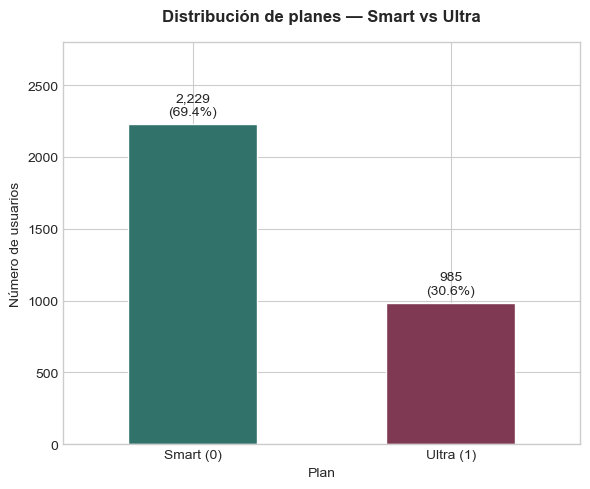

In [77]:
fig, ax = plt.subplots(figsize=(6, 5))

plan_counts.plot(kind='bar', ax=ax, color=["#31726A", "#803952"], width=0.5, edgecolor='white')
ax.set_title('Distribución de planes — Smart vs Ultra', fontweight='bold', pad=15)
ax.set_xlabel('Plan')
ax.set_ylabel('Número de usuarios')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Smart (0)', 'Ultra (1)'], rotation=0)
ax.bar_label(ax.containers[0], labels=[f'{v:,}\n({v/len(df)*100:.1f}%)' for v in plan_counts], padding=4)
ax.set_ylim(0, 2800)

plt.tight_layout()
plt.show()

### 3b — Distribución de features por plan

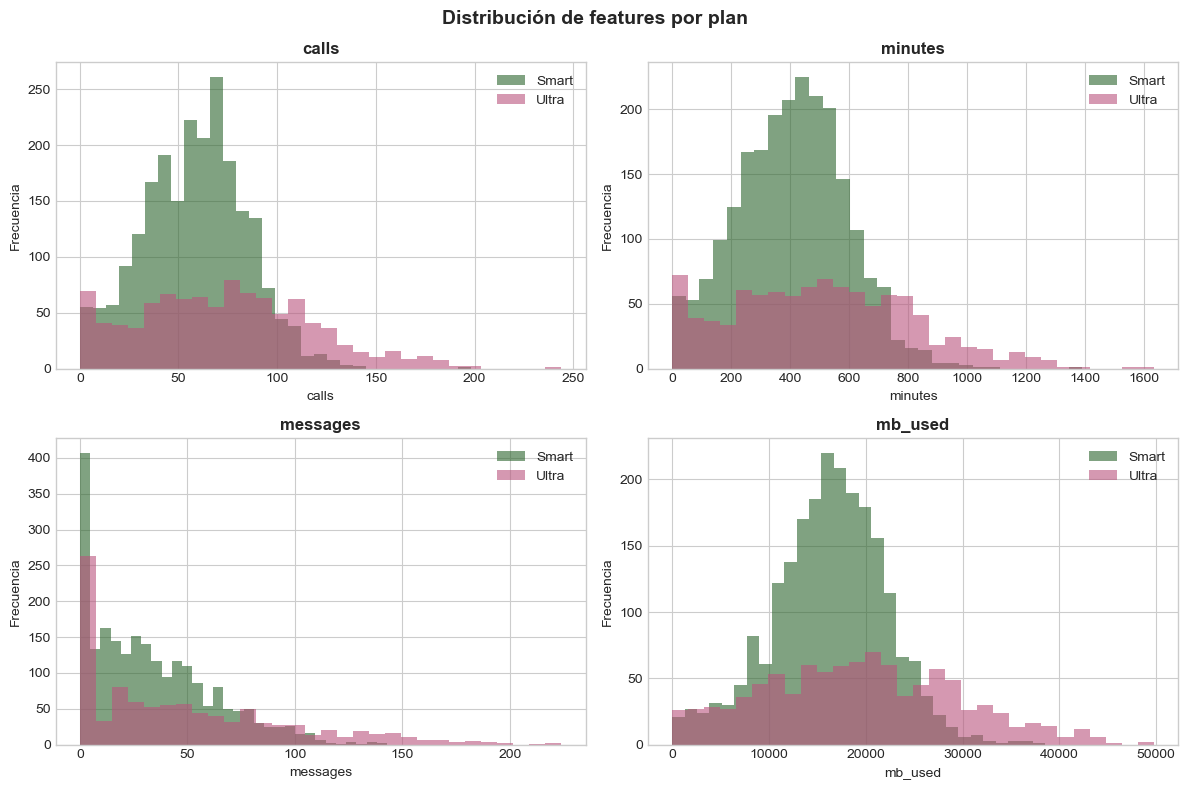

In [78]:
features_list = ['calls', 'minutes', 'messages', 'mb_used']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(features_list):
    for plan, color, label in [(0, "#2C652D", 'Smart'), (1, "#B9547D", 'Ultra')]:
        axes[i].hist(df[df['is_ultra'] == plan][col], bins=30, alpha=0.6, color=color, label=label)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend()

plt.suptitle('Distribución de features por plan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3c — Boxplots por plan

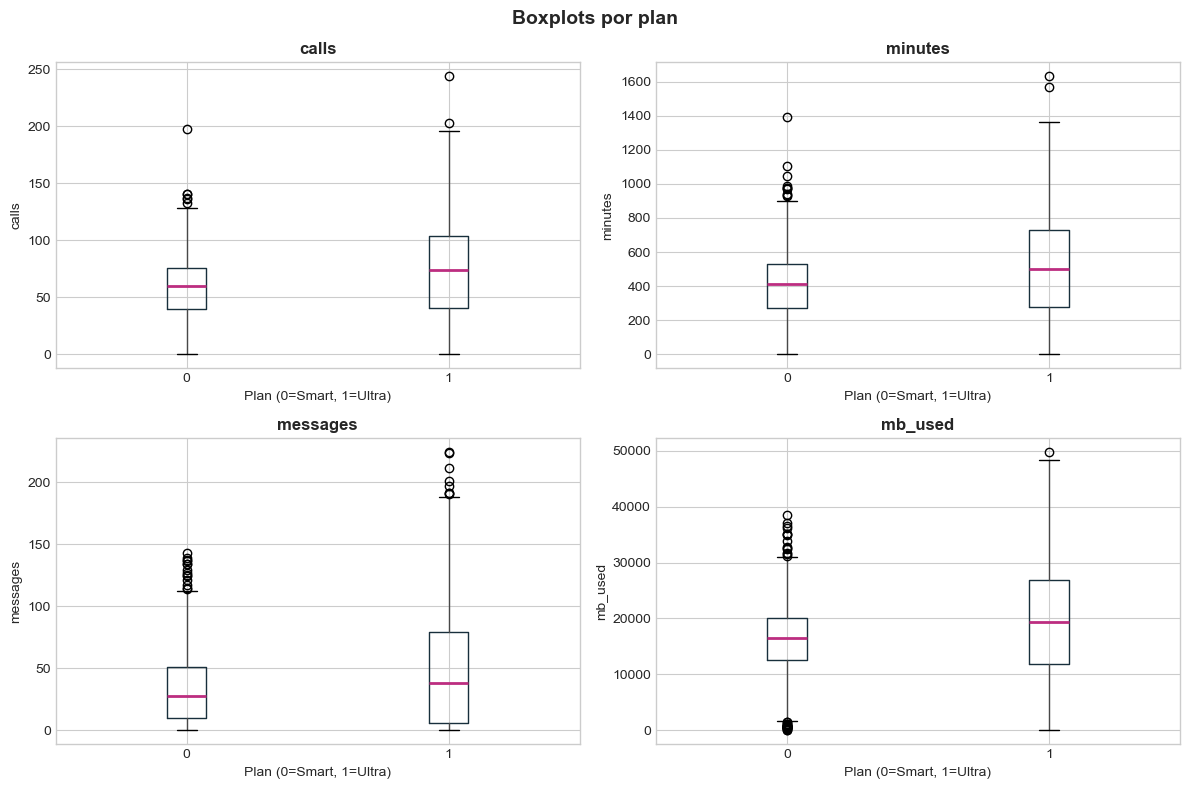

In [79]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(features_list):
    df.boxplot(column=col, by='is_ultra', ax=axes[i], 
               boxprops=dict(color="#182F3C"),
               medianprops=dict(color="#BC2D80", linewidth=2))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Plan (0=Smart, 1=Ultra)')
    axes[i].set_ylabel(col)

plt.suptitle('Boxplots por plan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3d — Heatmap de correlación

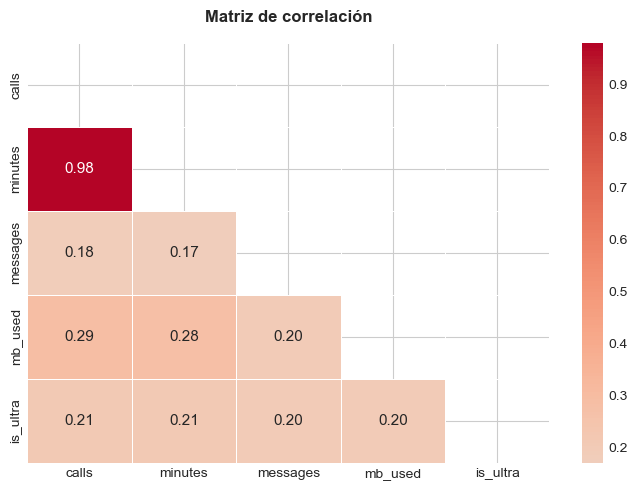

In [80]:
fig, ax = plt.subplots(figsize=(7, 5))

mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr().round(2), mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 11})

ax.set_title('Matriz de correlación', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Observaciones del análisis exploratorio

- **Desbalance de clases:** el 69.4% de usuarios está en Smart y solo el 30.6% en Ultra. Un modelo que prediga siempre Smart tendría 69% de exactitud sin aprender nada — por eso el umbral de 0.75 es el mínimo real de valor.

- **Usuarios Ultra consumen más en todo:** mayor promedio en llamadas (+25%), minutos (+26%), mensajes (+48%) y datos (+20%). El plan Ultra atrae a usuarios de uso intensivo en todas las dimensiones.

- **`calls` y `minutes` están casi perfectamente correlacionadas (0.98):** esto es esperado — más llamadas implica más minutos. Para modelos lineales esto puede ser problemático (multicolinealidad), pero los árboles de decisión lo manejan bien.

- **Ninguna feature domina la predicción:** todas tienen correlación similar con `is_ultra` (~0.20). Esto indica que el modelo necesita combinar las cuatro variables para clasificar correctamente — no existe una sola variable que por sí sola explique el plan.

- **Alta dispersión en usuarios Ultra:** la desviación estándar de todas las features es mayor en Ultra que en Smart. Los usuarios Ultra son más heterogéneos en su comportamiento.

## Sección 4 — Segmentación de datos

Dividimos el dataset en tres conjuntos: entrenamiento, validación y prueba. Usamos la estrategia 60/20/20.

- **Train (60%):** el modelo aprende de estos datos
- **Validation (20%):** comparamos modelos y ajustamos hiperparámetros
- **Test (20%):** evaluación final — se toca una sola vez al final

Usamos `stratify` para garantizar que los tres conjuntos mantengan la misma proporción de clases (69% Smart / 31% Ultra). Sin esto, por azar podría quedar un conjunto con más Ultras que otro y las métricas serían inconsistentes.

In [81]:
features = df.drop('is_ultra', axis=1)
target = df['is_ultra']

X_temp, X_test, y_temp, y_test = train_test_split(
    features, target, test_size=0.20, random_state=SEED, stratify=target
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

print(f'Train:      {X_train.shape[0]:,} filas ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Validation: {X_valid.shape[0]:,} filas ({X_valid.shape[0]/len(df)*100:.0f}%)')
print(f'Test:       {X_test.shape[0]:,} filas ({X_test.shape[0]/len(df)*100:.0f}%)')
print()
print('Balance de clases por conjunto:')
for nombre, y in [('Train', y_train), ('Validation', y_valid), ('Test', y_test)]:
    print(f'  {nombre:12} Ultra={y.mean()*100:.1f}%  Smart={100-y.mean()*100:.1f}%')

Train:      1,928 filas (60%)
Validation: 643 filas (20%)
Test:       643 filas (20%)

Balance de clases por conjunto:
  Train        Ultra=30.7%  Smart=69.3%
  Validation   Ultra=30.6%  Smart=69.4%
  Test         Ultra=30.6%  Smart=69.4%


## Sección 5 — Entrenamiento y búsqueda de hiperparámetros

Entrenamos tres modelos distintos y buscamos la mejor configuración de hiperparámetros para cada uno. Toda la comparación se hace sobre el conjunto de **validación** — el test no se toca hasta la sección 7.

### 5a — Decision Tree

Probamos profundidades de 1 a 15. A mayor profundidad el árbol aprende más patrones, pero también corre más riesgo de memorizar el ruido del entrenamiento (overfitting).

In [82]:
dt_results = []

for depth in range(1, 16):
    model = DecisionTreeClassifier(max_depth=depth, random_state=SEED)
    model.fit(X_train, y_train)
    acc_train = accuracy_score(y_train, model.predict(X_train))
    acc_valid = accuracy_score(y_valid, model.predict(X_valid))
    dt_results.append({
        'max_depth': depth,
        'acc_train': round(acc_train, 4),
        'acc_valid': round(acc_valid, 4),
        'gap': round(acc_train - acc_valid, 4)
    })

dt_df = pd.DataFrame(dt_results)
best_dt = dt_df.loc[dt_df['acc_valid'].idxmax()]
print(dt_df.to_string(index=False))
print(f'\nMejor: max_depth={int(best_dt.max_depth)}  Accuracy validación={best_dt.acc_valid}')

 max_depth  acc_train  acc_valid    gap
         1     0.7516     0.7325 0.0191
         2     0.7858     0.7652 0.0206
         3     0.8003     0.7776 0.0227
         4     0.8086     0.7823 0.0263
         5     0.8159     0.7900 0.0258
         6     0.8262     0.7807 0.0455
         7     0.8408     0.7760 0.0647
         8     0.8558     0.7792 0.0766
         9     0.8698     0.7714 0.0984
        10     0.8849     0.7621 0.1228
        11     0.8989     0.7589 0.1399
        12     0.9144     0.7621 0.1524
        13     0.9305     0.7558 0.1747
        14     0.9404     0.7558 0.1845
        15     0.9518     0.7574 0.1944

Mejor: max_depth=5  Accuracy validación=0.79


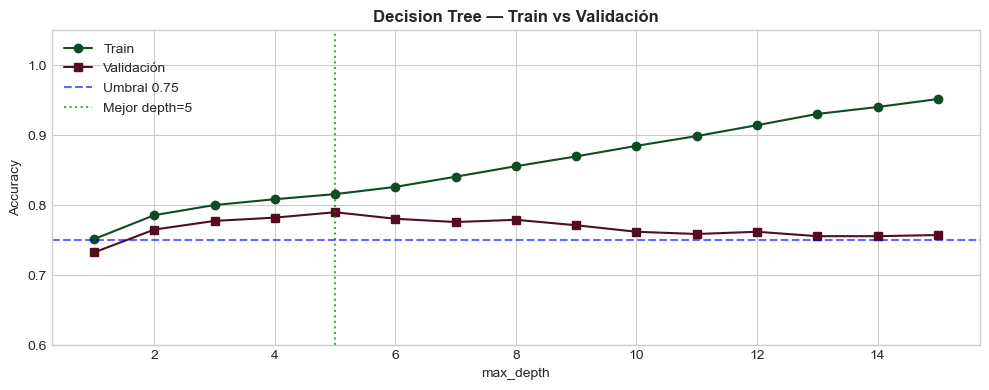

In [83]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(dt_df['max_depth'], dt_df['acc_train'], 'o-', label='Train', color="#0F4B23")
ax.plot(dt_df['max_depth'], dt_df['acc_valid'], 's-', label='Validación', color="#540C1F")
ax.axhline(0.75, color='blue', linestyle='--', alpha=0.6, label='Umbral 0.75')
ax.axvline(best_dt.max_depth, color='green', linestyle=':', alpha=0.7, 
           label=f'Mejor depth={int(best_dt.max_depth)}')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree — Train vs Validación', fontweight='bold')
ax.legend()
ax.set_ylim(0.6, 1.05)

plt.tight_layout()
plt.show()

El overfitting es visible: a partir de depth=5 el train sigue subiendo pero la validación empieza a bajar. Eso es un diagnóstico claro.
Mejor: max_depth=5, Accuracy validación=0.7961
Supera el umbral de 0.75. ✓

### 5b — Random Forest

Probamos combinaciones de número de árboles y profundidad máxima. El bosque aleatorio reduce el overfitting promediando múltiples árboles entrenados en subconjuntos aleatorios del dataset.

In [84]:
rf_results = []

for n_est in [10, 20, 30, 50, 80, 100]:
    for depth in [3, 5, 7, 10, None]:
        model = RandomForestClassifier(
            n_estimators=n_est, max_depth=depth, random_state=SEED, n_jobs=-1
        )
        model.fit(X_train, y_train)
        acc_train = accuracy_score(y_train, model.predict(X_train))
        acc_valid = accuracy_score(y_valid, model.predict(X_valid))
        rf_results.append({
            'n_estimators': n_est,
            'max_depth': str(depth),
            'acc_train': round(acc_train, 4),
            'acc_valid': round(acc_valid, 4),
            'gap': round(acc_train - acc_valid, 4)
        })

rf_df = pd.DataFrame(rf_results)
best_rf = rf_df.loc[rf_df['acc_valid'].idxmax()]
print('Top 10 configuraciones:')
print(rf_df.sort_values('acc_valid', ascending=False).head(10).to_string(index=False))
print(f'\nMejor: n_estimators={best_rf.n_estimators}, max_depth={best_rf.max_depth}, Accuracy={best_rf.acc_valid}')

Top 10 configuraciones:
 n_estimators max_depth  acc_train  acc_valid    gap
           30         7     0.8501     0.7963 0.0538
           50         7     0.8553     0.7963 0.0590
          100         7     0.8517     0.7932 0.0585
           20        10     0.8895     0.7932 0.0964
           80         7     0.8532     0.7916 0.0616
           20         7     0.8480     0.7916 0.0564
           10        10     0.8843     0.7900 0.0943
           30        10     0.8895     0.7900 0.0995
           10         7     0.8491     0.7885 0.0606
           20         3     0.8060     0.7885 0.0175

Mejor: n_estimators=30, max_depth=7, Accuracy=0.7963


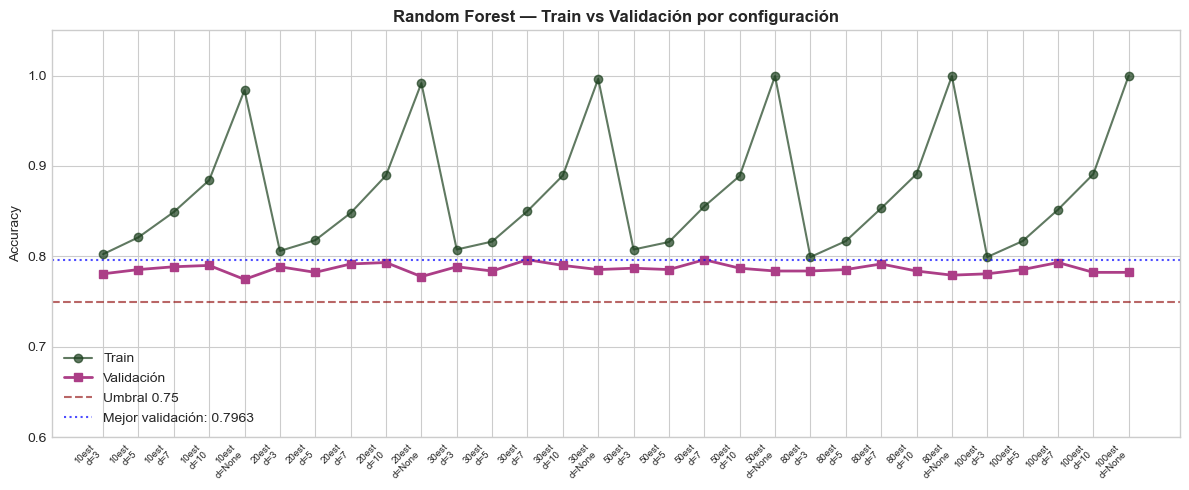

In [85]:
fig, ax = plt.subplots(figsize=(12, 5))

x = range(len(rf_df))
ax.plot(x, rf_df['acc_train'], 'o-', color="#1C401E", alpha=0.7, label='Train', linewidth=1.5)
ax.plot(x, rf_df['acc_valid'], 's-', color="#AC3E87", linewidth=2, label='Validación')
ax.axhline(0.75, color='darkred', linestyle='--', alpha=0.6, label='Umbral 0.75')
ax.axhline(best_rf.acc_valid, color='blue', linestyle=':', alpha=0.7,
           label=f'Mejor validación: {best_rf.acc_valid}')

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r.n_estimators}est\nd={r.max_depth}" for _, r in rf_df.iterrows()],
    fontsize=7, rotation=45, ha='right'
)
ax.set_ylabel('Accuracy')
ax.set_title('Random Forest — Train vs Validación por configuración', fontweight='bold')
ax.set_ylim(0.6, 1.05)
ax.legend()

plt.tight_layout()
plt.show()

### 5c — Logistic Regression

Probamos diferentes valores de C, que controla la regularización. Un C pequeño aplica más regularización (modelo más simple), un C grande aplica menos (modelo más flexible). Este modelo requiere normalización de features porque es sensible a la escala.

In [86]:
lr_results = []

for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(C=C, max_iter=1000, random_state=SEED, solver='lbfgs'))
    ])
    pipe.fit(X_train, y_train)
    acc_train = accuracy_score(y_train, pipe.predict(X_train))
    acc_valid = accuracy_score(y_valid, pipe.predict(X_valid))
    lr_results.append({
        'C': C,
        'acc_train': round(acc_train, 4),
        'acc_valid': round(acc_valid, 4),
        'gap': round(acc_train - acc_valid, 4)
    })

lr_df = pd.DataFrame(lr_results)
best_lr = lr_df.loc[lr_df['acc_valid'].idxmax()]
print(lr_df.to_string(index=False))
print(f'\nMejor: C={best_lr.C}, Accuracy validación={best_lr.acc_valid}')

      C  acc_train  acc_valid     gap
  0.001     0.7033     0.7045 -0.0012
  0.010     0.7412     0.7356  0.0056
  0.100     0.7464     0.7449  0.0014
  1.000     0.7464     0.7449  0.0014
 10.000     0.7469     0.7449  0.0019
100.000     0.7469     0.7449  0.0019

Mejor: C=0.1, Accuracy validación=0.7449


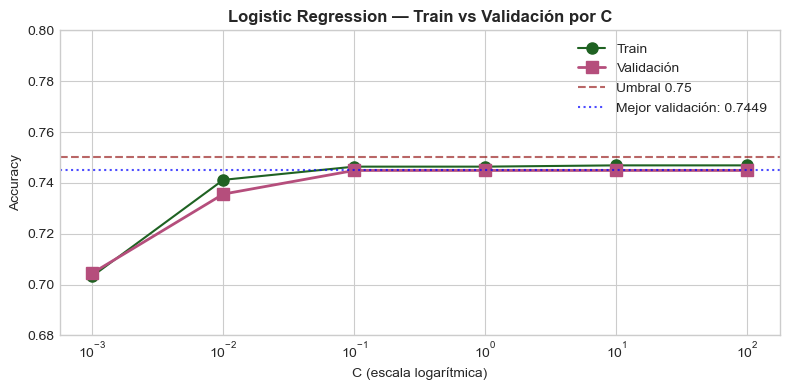

In [87]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(lr_df['C'], lr_df['acc_train'], 'o-', color="#1F6222", label='Train', linewidth=1.5, markersize=8)
ax.plot(lr_df['C'], lr_df['acc_valid'], 's-', color="#B54E7C", label='Validación', linewidth=2, markersize=8)
ax.axhline(0.75, color='darkred', linestyle='--', alpha=0.6, label='Umbral 0.75')
ax.axhline(best_lr.acc_valid, color='blue', linestyle=':', alpha=0.7,
           label=f'Mejor validación: {best_lr.acc_valid}')
ax.set_xscale('log')
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy')
ax.set_title('Logistic Regression — Train vs Validación por C', fontweight='bold')
ax.set_ylim(0.68, 0.80)
ax.legend()

plt.tight_layout()
plt.show()

## Sección 6 — Comparación de modelos

Reunimos los mejores resultados de cada modelo y elegimos el ganador basándonos en la accuracy del conjunto de validación.

In [88]:
comparison = pd.DataFrame([
    {
        'Modelo': 'Decision Tree',
        'Mejor configuración': f'max_depth={int(best_dt.max_depth)}',
        'Accuracy Train': best_dt.acc_train,
        'Accuracy Validación': best_dt.acc_valid,
        'Gap': best_dt.gap
    },
    {
        'Modelo': 'Random Forest',
        'Mejor configuración': f'n_estimators={best_rf.n_estimators}, depth={best_rf.max_depth}',
        'Accuracy Train': best_rf.acc_train,
        'Accuracy Validación': best_rf.acc_valid,
        'Gap': best_rf.gap
    },
    {
        'Modelo': 'Logistic Regression',
        'Mejor configuración': f'C={best_lr.C}',
        'Accuracy Train': best_lr.acc_train,
        'Accuracy Validación': best_lr.acc_valid,
        'Gap': best_lr.gap
    }
])

comparison = comparison.sort_values('Accuracy Validación', ascending=False).reset_index(drop=True)
comparison['Supera 0.75'] = comparison['Accuracy Validación'] >= 0.75
print(comparison.to_string(index=False))

             Modelo      Mejor configuración  Accuracy Train  Accuracy Validación    Gap  Supera 0.75
      Random Forest n_estimators=30, depth=7          0.8501               0.7963 0.0538         True
      Decision Tree              max_depth=5          0.8159               0.7900 0.0258         True
Logistic Regression                    C=0.1          0.7464               0.7449 0.0014        False


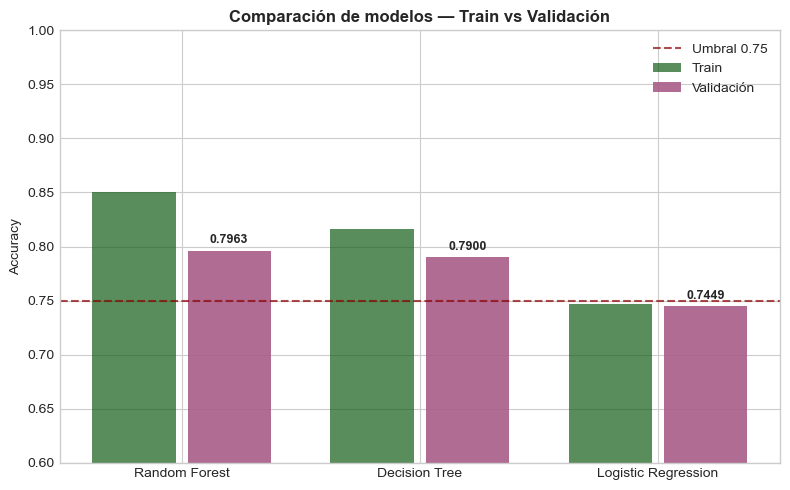

In [89]:
fig, ax = plt.subplots(figsize=(8, 5))

modelos = comparison['Modelo']
acc_train = comparison['Accuracy Train']
acc_valid = comparison['Accuracy Validación']
x = range(len(modelos))

bars1 = ax.bar([i - 0.2 for i in x], acc_train, width=0.35, 
               color="#135D16", alpha=0.7, label='Train')
bars2 = ax.bar([i + 0.2 for i in x], acc_valid, width=0.35, 
               color="#A85C87", alpha=0.9, label='Validación')

ax.axhline(0.75, color='darkred', linestyle='--', alpha=0.7, label='Umbral 0.75')
ax.bar_label(bars2, fmt='%.4f', padding=3, fontweight='bold', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=10)
ax.set_ylabel('Accuracy')
ax.set_ylim(0.6, 1.0)
ax.set_title('Comparación de modelos — Train vs Validación', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

### Decisión

El modelo seleccionado es **Random Forest** con `n_estimators=30` y `max_depth=7`. Supera el umbral requerido de 0.75, tiene el mejor accuracy en validación y un gap train-validación moderado (0.054) que indica buena generalización sin memorizar los datos de entrenamiento.

La Regresión Logística no supera el umbral porque asume relaciones lineales entre las features y el target — una limitación real dado que el comportamiento de uso de los clientes no sigue patrones lineales simples.

## Sección 7 — Evaluación final en test

Reentrenamos el modelo ganador usando train + validation para maximizar los datos de aprendizaje. Luego lo evaluamos una sola vez sobre el conjunto de test — el resultado que reportamos como rendimiento real del modelo.

In [90]:
X_full_train = pd.concat([X_train, X_valid])
y_full_train = pd.concat([y_train, y_valid])

final_model = RandomForestClassifier(
    n_estimators=30,
    max_depth=7,
    random_state=SEED,
    n_jobs=-1
)
final_model.fit(X_full_train, y_full_train)

y_pred_test = final_model.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_test)

print(f'Accuracy en test: {acc_test:.4f}')
print(f'Supera umbral 0.75: {"✓ SÍ" if acc_test >= 0.75 else "✗ NO"}')
print()
print(classification_report(y_test, y_pred_test, target_names=['Smart (0)', 'Ultra (1)']))

Accuracy en test: 0.8180
Supera umbral 0.75: ✓ SÍ

              precision    recall  f1-score   support

   Smart (0)       0.81      0.96      0.88       446
   Ultra (1)       0.84      0.50      0.63       197

    accuracy                           0.82       643
   macro avg       0.83      0.73      0.75       643
weighted avg       0.82      0.82      0.80       643



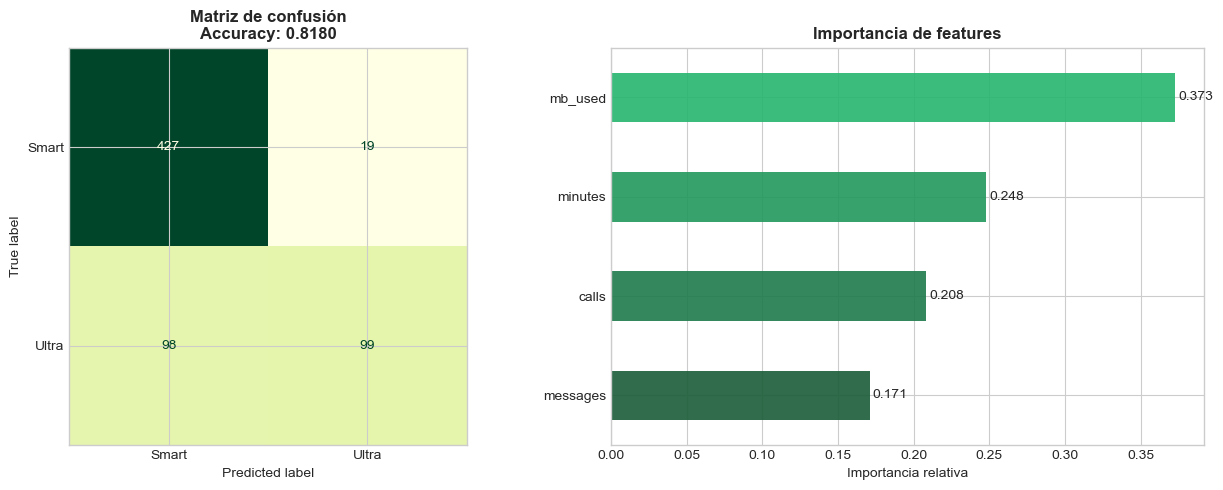

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Smart', 'Ultra'])
disp.plot(ax=axes[0], colorbar=False, cmap='YlGn')
axes[0].set_title(f'Matriz de confusión\nAccuracy: {acc_test:.4f}', fontweight='bold')

feat_imp = pd.Series(
    final_model.feature_importances_,
    index=features.columns
).sort_values()

colors = ['#1a5c38', '#1e7a4a', '#22985c', '#26b56e']
feat_imp.plot(kind='barh', ax=axes[1], color=colors, alpha=0.9)
axes[1].set_title('Importancia de features', fontweight='bold')
axes[1].set_xlabel('Importancia relativa')
for i, v in enumerate(feat_imp):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Sección 8 — Prueba de cordura

Comparamos el modelo contra dos baselines triviales para confirmar que realmente aprendió algo y no solo está aprovechando el desbalance de clases.

- **Baseline mayoritario:** predice siempre Smart (la clase más frecuente)
- **Baseline aleatorio:** predice aleatoriamente respetando la distribución del dataset

In [92]:
dummy_majority = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy_majority.fit(X_train, y_train)
acc_majority = accuracy_score(y_test, dummy_majority.predict(X_test))

dummy_random = DummyClassifier(strategy='stratified', random_state=SEED)
dummy_random.fit(X_train, y_train)
acc_random = accuracy_score(y_test, dummy_random.predict(X_test))

print(f'Baseline mayoritario:  {acc_majority:.4f}')
print(f'Baseline aleatorio:    {acc_random:.4f}')
print(f'Random Forest (final): {acc_test:.4f}')
print()
print(f'Mejora vs baseline mayoritario: +{(acc_test - acc_majority)*100:.2f} puntos porcentuales')
print(f'Prueba de cordura: {"✓ APROBADA" if acc_test > acc_majority else "✗ FALLIDA"}')

Baseline mayoritario:  0.6936
Baseline aleatorio:    0.5910
Random Forest (final): 0.8180

Mejora vs baseline mayoritario: +12.44 puntos porcentuales
Prueba de cordura: ✓ APROBADA


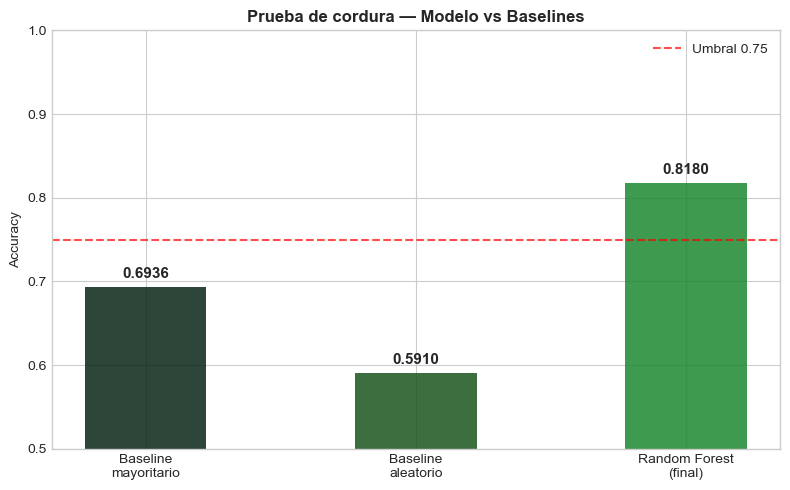

In [93]:
fig, ax = plt.subplots(figsize=(8, 5))

modelos_sanity = ['Baseline\nmayoritario', 'Baseline\naleatorio', 'Random Forest\n(final)']
accs_sanity = [acc_majority, acc_random, acc_test]
colors_sanity = ["#092516", "#1a551e", "#1b882f"]

bars = ax.bar(modelos_sanity, accs_sanity, color=colors_sanity, alpha=0.85, width=0.45)
ax.axhline(0.75, color='red', linestyle='--', alpha=0.7, label='Umbral 0.75')
ax.bar_label(bars, fmt='%.4f', padding=4, fontweight='bold', fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('Prueba de cordura — Modelo vs Baselines', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

## Sección 9 — Conclusiones

### Resultados del modelo final

| Métrica | Valor |
|---------|-------|
| Modelo seleccionado | Random Forest |
| Configuración | n_estimators=30, max_depth=7 |
| Accuracy en validación | 0.7963 |
| Accuracy en test | 0.8180 |
| Umbral requerido | 0.75 ✓ |
| Mejora vs baseline | +12.44 puntos porcentuales |

### Hallazgos clave

- **`mb_used` es la variable más predictiva (37.3%):** el consumo de datos es el mejor indicador de si un cliente debería estar en Ultra. Tiene más peso que las llamadas y los minutos combinados.

- **El Random Forest superó a los demás modelos** porque captura relaciones no lineales entre variables — algo que la Regresión Logística no puede hacer por su naturaleza lineal.

- **El desbalance de clases (69%/31%) no comprometió el modelo:** gracias al split estratificado y a que Random Forest maneja bien el desbalance moderado. Sin embargo, el modelo comete más errores en Ultra (98 falsos negativos) que en Smart (19 falsos positivos) — un área de mejora futura.

- **La Regresión Logística no superó el umbral (0.7449):** esto confirma que la relación entre comportamiento de uso y tipo de plan no es lineal. Los patrones son más complejos de lo que una línea recta puede capturar.

### Recomendación de negocio

Megaline puede usar este modelo para identificar automáticamente a los clientes en planes heredados que tienen perfil de usuario Ultra — especialmente aquellos con alto consumo de datos (`mb_used` > percentil 75). Una campaña dirigida a ese segmento tendría una tasa de conversión significativamente mayor que una campaña masiva.

### Próximos pasos

- Aplicar técnicas de balanceo de clases (SMOTE) para mejorar la detección de usuarios Ultra
- Explorar XGBoost o LightGBM como alternativas al Random Forest
- Implementar el modelo como API REST para integración con el CRM de Megaline
- Monitorear el rendimiento del modelo en producción y reentrenar trimestralmente